# RAPPORT – Visualisation du graphe et du plus court chemin

Ce notebook reconstruit le graphe utilisé dans `dijkstra_tp.py`, affiche le diagramme et met en évidence le plus court chemin entre `a` et `e`.

# RAPPORT — TP Dijkstra

Ce notebook contient :
- `graph.py`
- `dijkstra_tp.py`
- `check_results.py`

Les cellules ci-dessous créent automatiquement les fichiers du TP, puis exécutent le programme principal et l'auto-correction.

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Reproduction du graphe de dijkstra_tp.py
G = nx.Graph()
edges = [
    ('a', 'b', 7),
    ('a', 'c', 9),
    ('a', 'f', 14),
    ('b', 'c', 10),
    ('b', 'd', 15),
    ('c', 'd', 11),
    ('c', 'f', 2),
    ('d', 'e', 6),
    ('e', 'f', 9),
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

source = 'a'
target = 'e'
shortest_path = nx.shortest_path(G, source=source, target=target, weight='weight')
shortest_length = nx.shortest_path_length(G, source=source, target=target, weight='weight')

print('Plus court chemin :', shortest_path)
print('Distance totale :', shortest_length)

Plus court chemin : ['a', 'c', 'f', 'e']
Distance totale : 20


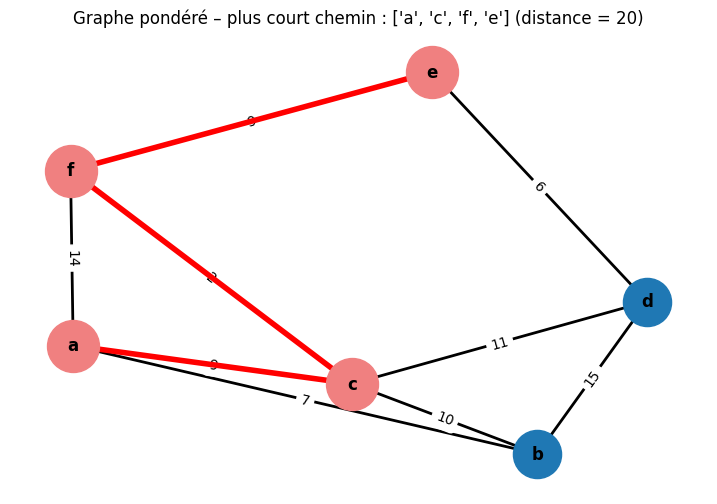

In [4]:
# Visualisation du graphe
pos = nx.spring_layout(G, seed=42)
edge_labels = nx.get_edge_attributes(G, 'weight')

# Arêtes du plus court chemin
path_edges = list(zip(shortest_path, shortest_path[1:]))

plt.figure(figsize=(9, 6))

# Graphe complet
nx.draw_networkx_nodes(G, pos, node_size=1200)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=2)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# Mise en évidence du plus court chemin
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_edges,
    width=4,
    edge_color='red'
)
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=shortest_path,
    node_size=1400,
    node_color='lightcoral'
)

plt.title(f'Graphe pondéré – plus court chemin : {shortest_path} (distance = {shortest_length})')
plt.axis('off')
plt.show()

##  Création de `check_results.py`

In [5]:

# check_results.py
from dijkstra_tp import shortest, g

target = g.get_vertex('e')
path = shortest(target)

expected_path = ['a', 'c', 'f', 'e']

if path == expected_path:
    print("✅ Bravo, le chemin est correct !")
else:
    print("❌ Chemin incorrect.")
    print("Votre chemin:", path)
    print("Chemin attendu:", expected_path)

Graph data:
( a , b,   7 )
( a , c,   9 )
( a , f,  14 )
( b , a,   7 )
( b , c,  10 )
( b , d,  15 )
( c , a,   9 )
( c , b,  10 )
( c , d,  11 )
( c , f,   2 )
( d , b,  15 )
( d , c,  11 )
( d , e,   6 )
( e , d,   6 )
( e , f,   9 )
( f , a,  14 )
( f , c,   2 )
( f , e,   9 )
updated : current = a next = b new_dist = 7
updated : current = a next = c new_dist = 9
updated : current = a next = f new_dist = 14
not updated : current = b next = c new_dist = 9
updated : current = b next = d new_dist = 22
updated : current = c next = d new_dist = 20
updated : current = c next = f new_dist = 11
updated : current = f next = e new_dist = 20
not updated : current = d next = e new_dist = 20
Le plus court chemin: ['a', 'c', 'f', 'e']
✅ Bravo, le chemin est correct !
